# ECML26 — Pipeline (neu aufgebaut, repo-losgelöst)

Spiegelt die Paper-Soll-Struktur **Block 1 → 2 → 3 → 4 → 5 → 6**, läuft auf dem
Stage-8-Parallel/SQLite-Motor und enthält die vier Neuerungen:

1. **tie-safe kNN-Purity** (`mode="prop"`) überall, wo Purity Strukturmetrik ist
2. **repeated-OOF-Correctness** je Kunde (`correct_rate_i`), verknüpft mit `purity_i`/`margin_i`
3. **korrigierte Modelle + Label-Arm** als dritter Modelltyp
4. **Parallelisierung + Fold-Cache** (SQLite-WAL, resume-fähig) als Motor

Alles orchestriert `ecml.*` — kein Repo-Layout-Bezug. `USE_SYNTHETIC=True` fährt end-to-end
ohne Echtdaten. Ausführen im **numpy<2-Env mit `proto_dist_ml==1.0.1`**.

In [1]:
from src import engine
from src.models import M3GLVQ_Global
import inspect
print("Key tokenlos?  ", engine.run_signature(150,10,42,42))          # -> 'T150|cv10|rs42|bs42' (ohne |code)
print("predict quadratisch?", "self._vWeights ** 2" in inspect.getsource(M3GLVQ_Global.predict))  # -> True

Key tokenlos?   T150|cv10|rs42|bs42
predict quadratisch? True


In [2]:
# --- Setup -------------------------------------------------------------------
import sys
from pathlib import Path

PKG_PARENT = Path.cwd()          # Ordner, der 'ecml/' enthält; ggf. anpassen
if str(PKG_PARENT) not in sys.path:
    sys.path.insert(0, str(PKG_PARENT))



import numpy as np, pandas as pd
from src import data, search, repeated_oof, engine, weight_profiles as WP
from src.single_view_mglvq.mglvq_fast import MGLVQ
from src.structural.run import run_structural_analysis
from src.single_view_mglvq.run import run_single_view_mglvq
from src.analysis.run import run_pointwise_analysis
from src.analysis import paper_tables as PT
from src.analysis.figures import plot_structure_vs_prediction_boxplot
print("ecml importiert.")

ecml importiert.


In [3]:
import os

print(os.getcwd())

/home/jovyan/work/workspace/1.0_project_repos/ECML26_new


In [4]:
from src.common.proto_init import DegenerateInitError as A
from src.models.proto_init import DegenerateInitError as B
print(A is B)   # muss True sein

True


In [5]:
# --- Konfiguration -----------------------------------------------------------
USE_SYNTHETIC = False
PRODUCT       = "0201"

REPO_DATA_DIR = None             # Path zu data/raw/... (Repo-Layout) — sonst None
FLAT = dict(                     # flache Uploads (nur bei USE_SYNTHETIC=False & REPO_DATA_DIR=None)
    matrix_paths=dict(
        naics="/home/jovyan/work/workspace/1.0_project_repos/ECML26/data/raw/D/ECML/0201/dissimilarity_naics_matrix.pkl",
        hs="/home/jovyan/work/workspace/1.0_project_repos/ECML26/data/raw/D/ECML/0201/dissimilarity_hs_matrix.pkl",
        am="/home/jovyan/work/workspace/1.0_project_repos/ECML26/data/raw/D/ECML/0201/dissimilarity_am_A_matrix.pkl",
    ),
    target_path="/home/jovyan/work/workspace/1.0_project_repos/ECML26/data/raw/y/ECML/0201/A.pkl",
    target_col="A",
)

OUT      = Path("outputs"); OUT.mkdir(exist_ok=True)
STRUCT   = OUT / "structural"
SV       = OUT / "single_view_mglvq"
ANALYSIS = OUT / "analysis"
CACHE_DB = OUT / f"cache_{PRODUCT}.sqlite"

N_JOBS = 3; BASE_SEED = 42; RANDOM_STATE = 42
if USE_SYNTHETIC:
    SEARCH = dict(T=60, n_splits=3);  ROOF = dict(T=60, n_splits=5, n_repeats=4)
else:
    SEARCH = dict(T=150, n_splits=3); ROOF = dict(T=150, n_splits=10, n_repeats=5)
print("USE_SYNTHETIC =", USE_SYNTHETIC)

USE_SYNTHETIC = False


In [6]:
# --- Daten laden (einmal aligned; alle Blöcke teilen die Kundenordnung) -------
if USE_SYNTHETIC:
    bundle = data.synthetic_bundle(m=120, seed=0)
elif REPO_DATA_DIR is not None:
    bundle = data.load_bundle(base_path=REPO_DATA_DIR, product=PRODUCT)
else:
    bundle = data.load_bundle(product=PRODUCT, **FLAT)

print("m =", len(bundle.y), "| Klassen:", dict(zip(*np.unique(bundle.y, return_counts=True))))
print("Views:", list(bundle.matrices_raw.keys()))

m = 2025 | Klassen: {0: 987, 1: 1038}
Views: ['naics', 'hs', 'am']


## Block 1 — Strukturanalyse (tie-safe Purity)
Single-view Summary + `pointwise_structure_df` (purity_i/margin_i je View, **tie-safe** `prop`),
Cross-View Korrelation/kNN-Overlap/Agreement.

In [7]:
struct = run_structural_analysis(
    matrices=bundle.matrices_raw, y=bundle.y_series,
    run_name=PRODUCT, out_root=STRUCT, k=10,
    n_perm=(10 if USE_SYNTHETIC else 50),
)
struct_dir = struct["run_dir"]
struct["single_summary_df"]

[WARN] Few valid points for 2NN intrinsic dimension: 15 / 2025


,matrix,n,sym_max_abs_diff,diag_min,diag_max,D_min,D_max,D_mean_all,D_std_all,dist_mean_ut,...,knn_purity_mean,n_class0,n_class1,knn_purity_baseline_mean,knn_purity_baseline_std,knn_purity_z,robust_mu_mean,robust_mu_std,robust_mu_frac_neg,robust_mu_frac_zero
0,naics,2025,0.0,0.0,0.0,0.0,1.0,0.852188,0.208230,0.852609,...,0.542185,987,1038,0.500355,0.002661,15.717320,-0.014774,0.135176,0.080000,0.879506
1,hs,2025,0.0,0.0,0.0,0.0,1.0,0.913360,0.147304,0.913811,...,0.522793,987,1038,0.500044,0.003073,7.402061,-0.007715,0.116938,0.320988,0.429136
2,am,2025,0.0,0.0,0.0,0.0,1.0,0.690013,0.199430,0.690354,...,0.519249,987,1038,0.500134,0.002187,8.741289,-0.000771,0.027603,0.156049,0.693333


## Block 2 — Single-View-MGLVQ (OOF-Baselines)
Grid über K, out-of-fold Predictions je View; verknüpft Struktur→Prädiktion punktweise.

In [8]:
# === Block 2 — Single-View-Baseline ===
from src.models import proto_init as PI
PI.RESCUE_LOG_PATH = str(OUT / "proto_rescues.jsonl")
PI.MAX_INIT_RETRIES = 8      # 0 = strikt wie vorher

from src import single_view_global as SVG
USE_GLOBAL_SINGLEVIEW = True

if USE_GLOBAL_SINGLEVIEW:
    sv_summary, sv_correct_wide = SVG.run_single_view_from_global(
        bundle.DL, bundle.y, bundle.codes, CACHE_DB,
        k_pairs=([(k0, k1) for k0 in range(3, 11) for k1 in range(3, 11)]   # volles 8x8-Gitter
                 if not USE_SYNTHETIC else [(3, 3), (3, 5), (5, 3)]),
        T=150 if not USE_SYNTHETIC else SEARCH["T"],
        n_splits=10 if not USE_SYNTHETIC else 3,
        random_state=RANDOM_STATE, base_seed=BASE_SEED, n_jobs=N_JOBS,
    )
    sv_dir = None
else:
    sv = run_single_view_mglvq(
        matrices=bundle.matrices_raw, y=bundle.y_series, model_cls=MGLVQ,
        run_name=PRODUCT, out_root=SV,
        n_splits=(3 if USE_SYNTHETIC else 5),
        param_grid={"K": [3, 5, 7]} if USE_SYNTHETIC else {"K": [3, 4, 5, 6, 7, 8, 9, 10]},
        pointwise_structure_df=struct["pointwise_structure_df"],
    )
    sv_summary = sv["summary_df"]; sv_correct_wide = None; sv_dir = sv["run_dir"]

display(sv_summary)

resc = PI.read_rescue_log(str(OUT / "proto_rescues.jsonl"))
print("Rescues gesamt:", len(resc))
resc.groupby(["view_tag", "label", "k"]).size()

,matrix,best_K,best_K0,best_K1,balanced_accuracy_from_oof,recall_from_oof,tp,fp,tn,fn,n_pairs_valid,n_pairs_total
0,naics,5/10,5,10,0.603717,0.652216,677,439,548,361,64,64
1,hs,6/5,6,5,0.576635,0.641618,666,482,505,372,64,64
2,am,3/3,3,3,0.555783,0.684008,710,565,422,328,32,64


Rescues gesamt: 0


Series([], dtype: int64)

### Pointwise-Merge (Struktur ⊕ Single-View)
`wide_df` mit `knn_purity_{naics,hs,am}` (tie-safe) und `correct_{...}` — Basis für Tab. 7/9 + Figur.

In [9]:
ps = struct["pointwise_structure_df"].copy()
ps["view"] = ps["view"].str.lower()
ps["customer_id"] = ps["id"].astype(str)          # id IST der Code

struct_wide = ps.pivot_table(index="customer_id", columns="view",
                             values=[c for c in ("knn_purity", "mu") if c in ps.columns])
struct_wide.columns = [f"{v}_{w}" for v, w in struct_wide.columns]
struct_wide = struct_wide.reset_index()

sv_correct_wide["customer_id"] = sv_correct_wide["customer_id"].astype(str)
wide_df = struct_wide.merge(sv_correct_wide, on="customer_id", how="inner")

ANALYSIS.mkdir(parents=True, exist_ok=True)
wide_df.to_csv(ANALYSIS / "structure_single_view_wide.csv", index=False)

print("gemergte Kunden:", len(wide_df),
      "| purity-Views:", [c for c in wide_df if c.startswith("knn_purity_")],
      "| correct-Views:", [c for c in wide_df if c.startswith("correct_")])
wide_df.head()

gemergte Kunden: 2025 | purity-Views: ['knn_purity_am', 'knn_purity_hs', 'knn_purity_naics'] | correct-Views: ['correct_naics', 'correct_hs', 'correct_am']


,customer_id,knn_purity_am,knn_purity_hs,knn_purity_naics,mu_am,mu_hs,mu_naics,y,correct_naics,correct_hs,correct_am
0,1,0.442857,0.5,0.380952,0.000000,0.000000,0.0,1,0.0,0.0,0.0
1,10,0.442857,0.8,0.655556,0.000000,-0.012245,0.0,1,0.0,1.0,0.0
2,100,0.775000,0.7,0.766667,-0.043478,-0.029412,-1.0,0,1.0,0.0,1.0
3,1000,0.355263,0.8,0.533333,0.045455,-0.076923,0.0,0,0.0,1.0,0.0
4,1001,0.595082,0.4,0.350000,0.000000,0.000000,0.0,0,0.0,0.0,1.0


## Block 3 — Multi-View-Suche (Engine: bestes (K, η) je Modelltyp)
Paralleler Grid über Global + Label auf dem Fold-Cache. `staged_search` (coarse→refine→finalists)
für den Echtlauf, `full_search` mit Mini-Grid für die Synthetik.

In [10]:
# === Block 3 — Multi-View-Suche (nur Global + Label) ===
engine.init_cache_db(CACHE_DB)
paper_k_pairs = [(k0, k1) for k0 in range(3, 11) for k1 in range(3, 11)]
paper_etas    = [0.03, 0.04, 0.05]
paper_etas = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]
paper_single_k = [3, 4, 5, 6, 7, 8, 9, 10]

if USE_SYNTHETIC:
    results, best = search.full_search(
        bundle.DL, bundle.y, CACHE_DB,
        T=SEARCH["T"], n_splits=SEARCH["n_splits"],
        random_state=RANDOM_STATE, base_seed=BASE_SEED, n_jobs=N_JOBS,
        run_single=False,                      # <- Single-View kommt aus Block 2
        k_pairs=[(3, 3), (5, 5)], etas=[0.02, 0.04],
    )
else:
    results, best = search.full_search(
        bundle.DL, bundle.y, CACHE_DB,
        T=150, n_splits=10,
        random_state=RANDOM_STATE, base_seed=BASE_SEED, n_jobs=N_JOBS,
        run_single=False,                      # <- Single-View kommt aus Block 2
        k_pairs=paper_k_pairs,
        etas=paper_etas,
    )

print("Beste Configs je Typ:")
for m_, c_ in best.items():
    print(" ", m_, c_)
results.sort_values("bal_acc", ascending=False).head(8)

Beste Configs je Typ:
  M3GLVQ_Label {'K0': 4, 'K1': 3, 'eta': 0.005, 'bal_acc': 0.571286551762508}
  M3GLVQ_Global {'K0': 5, 'K1': 5, 'eta': 0.01, 'bal_acc': 0.5781957353104814}


,model,K,eta,acc,bal_acc,f1_macro,status,note,key,stage
218,M3GLVQ_Global,5/5,0.010,0.579259,0.578196,0.577898,ok,,M3GLVQ_Global|K5/5|eta0.01|T150|cv10|rs42|bs42,full
26,M3GLVQ_Global,3/5,0.010,0.577778,0.574162,0.566964,ok,,M3GLVQ_Global|K3/5|eta0.01|T150|cv10|rs42|bs42,full
14,M3GLVQ_Global,3/4,0.010,0.576790,0.573074,0.565388,ok,,M3GLVQ_Global|K3/4|eta0.01|T150|cv10|rs42|bs42,full
108,M3GLVQ_Global,4/4,0.005,0.575309,0.572575,0.568789,ok,,M3GLVQ_Global|K4/4|eta0.005|T150|cv10|rs42|bs42,full
97,M3GLVQ_Label,4/3,0.005,0.572840,0.571287,0.570355,ok,,M3GLVQ_Label|K4/3|eta0.005|T150|cv10|rs42|bs42,full
150,M3GLVQ_Global,4/7,0.030,0.572346,0.569834,0.566707,ok,,M3GLVQ_Global|K4/7|eta0.03|T150|cv10|rs42|bs42,full
1,M3GLVQ_Label,3/3,0.005,0.572346,0.568341,0.559099,ok,,M3GLVQ_Label|K3/3|eta0.005|T150|cv10|rs42|bs42,full
206,M3GLVQ_Global,5/4,0.010,0.569383,0.568114,0.567573,ok,,M3GLVQ_Global|K5/4|eta0.01|T150|cv10|rs42|bs42,full


### Block 3a — Zusatzexperimente


In [11]:
# === Exp 2 — gezielte η-Verfeinerung (hängt an denselben Cache an) ===
exp2_k_pairs = [(3,3),(3,4),(4,3),(4,4),(5,3),(5,4),(5,5),(5,6)]
exp2_etas    = [0.0025, 0.0075, 0.0125, 0.015, 0.0175]

results_exp2, best_exp2 = search.full_search(
    bundle.DL, bundle.y, CACHE_DB,
    T=150, n_splits=10,
    random_state=RANDOM_STATE, base_seed=BASE_SEED, n_jobs=N_JOBS,
    run_single=False,                 # Single-View kommt aus Block 2 (svglobal)
    k_pairs=exp2_k_pairs,
    etas=exp2_etas,
)

print("Exp 2 — beste Config je Typ im verfeinerten Bereich:")
for m_, c_ in best_exp2.items():
    print(" ", m_, c_)

results_exp2.sort_values("bal_acc", ascending=False).head(10)

Exp 2 — beste Config je Typ im verfeinerten Bereich:
  M3GLVQ_Label {'K0': 5, 'K1': 3, 'eta': 0.0025, 'bal_acc': 0.5814006945786554}
  M3GLVQ_Global {'K0': 3, 'K1': 3, 'eta': 0.015, 'bal_acc': 0.5833801851819316}


,model,K,eta,acc,bal_acc,f1_macro,status,note,key,stage
6,M3GLVQ_Global,3/3,0.0150,0.586667,0.583380,0.577767,ok,,M3GLVQ_Global|K3/3|eta0.015|T150|cv10|rs42|bs42,full
41,M3GLVQ_Label,5/3,0.0025,0.581728,0.581401,0.581408,ok,,M3GLVQ_Label|K5/3|eta0.0025|T150|cv10|rs42|bs42,full
4,M3GLVQ_Global,3/3,0.0125,0.584198,0.580847,0.574930,ok,,M3GLVQ_Global|K3/3|eta0.0125|T150|cv10|rs42|bs42,full
22,M3GLVQ_Global,4/3,0.0075,0.577284,0.575647,0.574595,ok,,M3GLVQ_Global|K4/3|eta0.0075|T150|cv10|rs42|bs42,full
54,M3GLVQ_Global,5/4,0.0125,0.575802,0.574923,0.574765,ok,,M3GLVQ_Global|K5/4|eta0.0125|T150|cv10|rs42|bs42,full
21,M3GLVQ_Label,4/3,0.0025,0.576296,0.574086,0.571822,ok,,M3GLVQ_Label|K4/3|eta0.0025|T150|cv10|rs42|bs42,full
11,M3GLVQ_Label,3/4,0.0025,0.577778,0.573042,0.559729,ok,,M3GLVQ_Label|K3/4|eta0.0025|T150|cv10|rs42|bs42,full
2,M3GLVQ_Global,3/3,0.0075,0.576790,0.572576,0.562336,ok,,M3GLVQ_Global|K3/3|eta0.0075|T150|cv10|rs42|bs42,full
52,M3GLVQ_Global,5/4,0.0075,0.570864,0.570654,0.570643,ok,,M3GLVQ_Global|K5/4|eta0.0075|T150|cv10|rs42|bs42,full
32,M3GLVQ_Global,4/4,0.0075,0.571358,0.569319,0.567429,ok,,M3GLVQ_Global|K4/4|eta0.0075|T150|cv10|rs42|bs42,full


In [12]:
import numpy as np
from sklearn.metrics import recall_score
from src import engine

def add_recall_from_cache(results_df, cache_db):
    """Ergänzt results_df um eine 'recall'-Spalte (Klasse 1), aus den gecachten Folds."""
    rec = {}
    for key in results_df["key"].unique():
        folds = engine.load_fold_cache(cache_db, key)
        yt, yp = [], []
        for c in folds.values():
            if c["status"] == "ok" and c["y_true"] is not None:
                yt.append(np.asarray(c["y_true"])); yp.append(np.asarray(c["y_pred"]))
        if yt:
            yt = np.concatenate(yt); yp = np.concatenate(yp)
            rec[key] = recall_score(yt, yp, pos_label=1, zero_division=0)
        else:
            rec[key] = np.nan
    out = results_df.copy()
    out["recall"] = out["key"].map(rec)
    return out

In [13]:
results_exp2 = add_recall_from_cache(results_exp2, CACHE_DB)
results_exp2.sort_values("bal_acc", ascending=False)[
    ["model", "K", "eta", "bal_acc", "recall", "f1_macro", "status"]
].head(10)

,model,K,eta,bal_acc,recall,f1_macro,status
6,M3GLVQ_Global,3/3,0.0150,0.583380,0.713873,0.577767,ok
41,M3GLVQ_Label,5/3,0.0025,0.581401,0.594412,0.581408,ok
4,M3GLVQ_Global,3/3,0.0125,0.580847,0.713873,0.574930,ok
22,M3GLVQ_Global,4/3,0.0075,0.575647,0.640655,0.574595,ok
54,M3GLVQ_Global,5/4,0.0125,0.574923,0.609827,0.574765,ok
21,M3GLVQ_Label,4/3,0.0025,0.574086,0.661850,0.571822,ok
11,M3GLVQ_Label,3/4,0.0025,0.573042,0.761079,0.559729,ok
2,M3GLVQ_Global,3/3,0.0075,0.572576,0.739884,0.562336,ok
52,M3GLVQ_Global,5/4,0.0075,0.570654,0.578998,0.570643,ok
32,M3GLVQ_Global,4/4,0.0075,0.569319,0.650289,0.567429,ok


In [14]:
import pandas as pd
all_results = pd.concat([results, results_exp2], ignore_index=True).drop_duplicates(subset=["key"])
all_results = add_recall_from_cache(all_results, CACHE_DB)
best_overall = search.best_configs(all_results, metric="bal_acc")
print("Gesamtbestes je Typ:")
for m_, c_ in best_overall.items(): print(" ", m_, c_)

all_results.sort_values("bal_acc", ascending=False)[
    ["model", "K", "eta", "bal_acc", "recall", "f1_macro"]
].head(12)

Gesamtbestes je Typ:
  M3GLVQ_Label {'K0': 5, 'K1': 3, 'eta': 0.0025, 'bal_acc': 0.5814006945786554}
  M3GLVQ_Global {'K0': 3, 'K1': 3, 'eta': 0.015, 'bal_acc': 0.5833801851819316}


,model,K,eta,bal_acc,recall,f1_macro
774,M3GLVQ_Global,3/3,0.0150,0.583380,0.713873,0.577767
809,M3GLVQ_Label,5/3,0.0025,0.581401,0.594412,0.581408
772,M3GLVQ_Global,3/3,0.0125,0.580847,0.713873,0.574930
218,M3GLVQ_Global,5/5,0.0100,0.578196,0.620424,0.577898
790,M3GLVQ_Global,4/3,0.0075,0.575647,0.640655,0.574595
822,M3GLVQ_Global,5/4,0.0125,0.574923,0.609827,0.574765
26,M3GLVQ_Global,3/5,0.0100,0.574162,0.717726,0.566964
789,M3GLVQ_Label,4/3,0.0025,0.574086,0.661850,0.571822
14,M3GLVQ_Global,3/4,0.0100,0.573074,0.720617,0.565388
779,M3GLVQ_Label,3/4,0.0025,0.573042,0.761079,0.559729


In [15]:
import numpy as np
from src import engine, search

def winner_weights(model, cfg, cache_db, T=150, n_splits=10, rs=RANDOM_STATE, bs=BASE_SEED):
    key = search.multi_key(model, cfg["K0"], cfg["K1"], cfg["eta"], T, n_splits, rs, bs)
    folds = engine.load_fold_cache(cache_db, key)
    vs = [c["vweights"] for c in folds.values() if c["status"]=="ok" and c["vweights"]]
    if not vs: 
        return print(f"{model}: keine Gewichte im Cache für {key}")
    if vs[0]["kind"] == "global":
        a = np.mean([np.asarray(v["a_sq"]) for v in vs], axis=0)
        print(f"\n{model}  (K={cfg['K0']}/{cfg['K1']}, η={cfg['eta']})")
        print("  a² (NAICS, HS, AM):", np.round(a,3), "| dominant:", ["NAICS","HS","AM"][a.argmax()])
    else:
        labs = vs[0]["labels"]
        a = np.mean([np.asarray(v["a_sq"]) for v in vs], axis=0)   # (L,V)
        print(f"\n{model}  (K={cfg['K0']}/{cfg['K1']}, η={cfg['eta']})")
        for li,l in enumerate(labs):
            print(f"  Label {l}: a² =", np.round(a[li],3), "| dominant:", ["NAICS","HS","AM"][a[li].argmax()])

for m_, c_ in best_overall.items():
    winner_weights(m_, c_, CACHE_DB)


M3GLVQ_Label  (K=5/3, η=0.0025)
  Label 0: a² = [0.338 0.341 0.32 ] | dominant: HS
  Label 1: a² = [0.342 0.328 0.329] | dominant: NAICS

M3GLVQ_Global  (K=3/3, η=0.015)
  a² (NAICS, HS, AM): [0.423 0.36  0.217] | dominant: NAICS


In [16]:
import numpy as np
from sklearn.metrics import balanced_accuracy_score, recall_score
from src import engine

def pooled_metrics_by_model(cache_db, models):
    con_rows = {}
    for name in models:
        import sqlite3
        con = sqlite3.connect(str(cache_db))
        rows = con.execute("SELECT config_key,y_true_json,y_pred_json,status FROM fold_results WHERE model=?", (name,)).fetchall()
        con.close()
        import json
        yt,yp=[],[]
        for _,a,b,st in rows:
            if st=="ok" and a: yt+=json.loads(a); yp+=json.loads(b)
        if yt:
            yt,yp=np.array(yt),np.array(yp)
            con_rows[name]=dict(bal_acc=balanced_accuracy_score(yt,yp),
                                recall=recall_score(yt,yp,pos_label=1,zero_division=0), n=len(yt))
    return con_rows

fixed = pooled_metrics_by_model(CACHE_DB, ["uniform","naics_only","hs_only","am_only"])
for k,v in fixed.items(): print(f"{k:12s} bal_acc={v['bal_acc']:.3f} recall={v['recall']:.3f}")
print("\nbestes gelerntes Global:", round(best_overall['M3GLVQ_Global']['bal_acc'],3))


bestes gelerntes Global: 0.583


In [17]:
import sqlite3, json
import numpy as np, pandas as pd
from sklearn.metrics import balanced_accuracy_score, recall_score, precision_score, f1_score

def config_metrics(cache_db, models=None, model_prefixes=None):
    """Poolt y_true/y_pred je Config aus dem Cache und berechnet die vollen Metriken.
    models: exakte Modellnamen; model_prefixes: Präfixe (z.B. 'svglobal::')."""
    con = sqlite3.connect(str(cache_db))
    rows = con.execute(
        "SELECT config_key, model, k_value, eta, y_true_json, y_pred_json, status "
        "FROM fold_results"
    ).fetchall()
    con.close()

    agg = {}
    for ck, model, kval, eta, yt, yp, st in rows:
        if st != "ok" or yt is None:
            continue
        d = agg.setdefault(ck, dict(model=model, K=kval, eta=eta, yt=[], yp=[], n=0))
        d["yt"] += json.loads(yt); d["yp"] += json.loads(yp); d["n"] += 1

    out = []
    for ck, d in agg.items():
        yt, yp = np.array(d["yt"]), np.array(d["yp"])
        tp = int(((yp == 1) & (yt == 1)).sum()); tn = int(((yp == 0) & (yt == 0)).sum())
        fp = int(((yp == 1) & (yt == 0)).sum()); fn = int(((yp == 0) & (yt == 1)).sum())
        out.append(dict(
            model=d["model"], K=d["K"], eta=d["eta"], n_folds=d["n"],
            bal_acc=balanced_accuracy_score(yt, yp),
            recall=recall_score(yt, yp, pos_label=1, zero_division=0),
            precision=precision_score(yt, yp, pos_label=1, zero_division=0),
            specificity=(tn / (tn + fp) if (tn + fp) else 0.0),
            f1=f1_score(yt, yp, pos_label=1, zero_division=0),
        ))
    df = pd.DataFrame(out)

    if models or model_prefixes:
        mask = df.model.isin(models or [])
        for p in (model_prefixes or []):
            mask |= df.model.str.startswith(p)
        df = df[mask]
    return df


# --- Multi-View + Single-Views ---
m = config_metrics(
    CACHE_DB,
    models=["M3GLVQ_Global", "M3GLVQ_Label"],
    model_prefixes=["svglobal::"],           # svglobal::naics / ::hs / ::am
)

show = ["M3GLVQ_Global", "M3GLVQ_Label",
        "svglobal::naics", "svglobal::hs", "svglobal::am"]

for model in show:
    d = m[m.model == model]
    if d.empty:
        print(f"\n### {model} — keine Zeilen im Cache")
        continue
    print(f"\n### {model} — Top 5 nach bal_acc")
    print(d.sort_values("bal_acc", ascending=False).head(5).round(3).to_string(index=False))
    print(f"### {model} — Top 5 nach recall")
    print(d.sort_values("recall", ascending=False).head(5).round(3).to_string(index=False))


### M3GLVQ_Global — Top 5 nach bal_acc
        model   K   eta  n_folds  bal_acc  recall  precision  specificity    f1
M3GLVQ_Global 3/3 0.015       10    0.583   0.714      0.578        0.453 0.639
M3GLVQ_Global 3/3 0.012       10    0.581   0.714      0.576        0.448 0.638
M3GLVQ_Global 5/5 0.010       10    0.578   0.620      0.584        0.536 0.602
M3GLVQ_Global 4/3 0.008       10    0.576   0.641      0.579        0.511 0.608
M3GLVQ_Global 5/4 0.012       10    0.575   0.610      0.582        0.540 0.596
### M3GLVQ_Global — Top 5 nach recall
        model    K   eta  n_folds  bal_acc  recall  precision  specificity    f1
M3GLVQ_Global 3/10 0.005       10    0.560   0.775      0.554        0.345 0.646
M3GLVQ_Global 3/10 0.050       10    0.562   0.750      0.557        0.373 0.640
M3GLVQ_Global 3/10 0.010       10    0.566   0.750      0.561        0.382 0.642
M3GLVQ_Global  3/4 0.002       10    0.568   0.742      0.563        0.394 0.640
M3GLVQ_Global  3/3 0.008       10    

## Experiment 3

In [18]:
# === Exp 3 — Smoke-Test (schnell, prüft dass alles läuft) ===
import shutil; shutil.rmtree(OUT / "exp3_smoke", ignore_errors=True)
from src import convergence as CONV

_smoke = CONV.run_convergence(
    bundle.DL, bundle.y, out_dir=OUT / "exp3_smoke",
    k_pairs=[(3,3)], etas=[0.01], T=100,
    checkpoints=[0, 25, 50, 100], n_splits=3,
    random_state=RANDOM_STATE, base_seed=BASE_SEED,
)
print("Smoke-Zeilen:", len(_smoke))
_smoke.head()

[conv] wrote M3GLVQ_Global_K3-3_eta0.01.parquet (1/2)
[conv] wrote M3GLVQ_Label_K3-3_eta0.01.parquet (2/2)
Smoke-Zeilen: 36


,model,K0,K1,eta,fold,checkpoint,iter_used,status,n_epochs_run,converged_before_T,...,train_loss,w_naics,w_hs,w_am,entropy,weight_drift,label_distance,proto_drift,val_bal_acc,val_recall
0,M3GLVQ_Global,3,3,0.01,1,0,0,ok,25,True,...,-13.478504,0.333333,0.333333,0.333333,1.00000,NaN,NaN,NaN,0.529736,0.554913
1,M3GLVQ_Global,3,3,0.01,1,25,25,ok,25,True,...,-114.119913,0.422820,0.320716,0.256463,0.98094,0.118643,NaN,0.909091,0.575434,0.786127
2,M3GLVQ_Global,3,3,0.01,1,50,25,ok,25,True,...,-114.119913,0.422820,0.320716,0.256463,0.98094,0.000000,NaN,0.000000,0.575434,0.786127
3,M3GLVQ_Global,3,3,0.01,1,100,25,ok,25,True,...,-114.119913,0.422820,0.320716,0.256463,0.98094,0.000000,NaN,0.000000,0.575434,0.786127
4,M3GLVQ_Global,3,3,0.01,2,0,0,ok,21,True,...,-27.105695,0.333333,0.333333,0.333333,1.00000,NaN,NaN,NaN,0.542641,0.526012


In [20]:
import shutil
shutil.rmtree(OUT / "exp3_convergence", ignore_errors=True)

In [21]:
# === Experiment 3 — Konvergenz-/Regularisierungs-Trajektorie ===
from src import convergence as CONV

traj = CONV.run_convergence(
    bundle.DL, bundle.y, out_dir=OUT / "exp3_convergence",
    k_pairs=[(3,3), (4,3), (5,3), (8,8)],
    etas=[0.005, 0.01],
    models=("M3GLVQ_Global", "M3GLVQ_Label"),
    T=500,
    checkpoints=[0, 25, 50, 75, 100, 150, 200, 300, 400, 500],
    n_splits=10, random_state=RANDOM_STATE, base_seed=BASE_SEED,
)
traj.to_parquet(OUT / "exp3_convergence" / "traj_all.parquet", index=False)
print("Trajektorien-Zeilen:", len(traj))
traj.head()

[conv] wrote M3GLVQ_Global_K3-3_eta0.005.parquet (1/16)
[conv] wrote M3GLVQ_Global_K3-3_eta0.01.parquet (2/16)
[conv] wrote M3GLVQ_Global_K4-3_eta0.005.parquet (3/16)
[conv] wrote M3GLVQ_Global_K4-3_eta0.01.parquet (4/16)
[conv] wrote M3GLVQ_Global_K5-3_eta0.005.parquet (5/16)
[conv] wrote M3GLVQ_Global_K5-3_eta0.01.parquet (6/16)
[conv] wrote M3GLVQ_Global_K8-8_eta0.005.parquet (7/16)
[conv] wrote M3GLVQ_Global_K8-8_eta0.01.parquet (8/16)
[conv] wrote M3GLVQ_Label_K3-3_eta0.005.parquet (9/16)
[conv] wrote M3GLVQ_Label_K3-3_eta0.01.parquet (10/16)
[conv] wrote M3GLVQ_Label_K4-3_eta0.005.parquet (11/16)
[conv] wrote M3GLVQ_Label_K4-3_eta0.01.parquet (12/16)
[conv] wrote M3GLVQ_Label_K5-3_eta0.005.parquet (13/16)
[conv] wrote M3GLVQ_Label_K5-3_eta0.01.parquet (14/16)
[conv] wrote M3GLVQ_Label_K8-8_eta0.005.parquet (15/16)
[conv] wrote M3GLVQ_Label_K8-8_eta0.01.parquet (16/16)
Trajektorien-Zeilen: 2400


,model,K0,K1,eta,fold,checkpoint,iter_used,status,n_epochs_run,converged_before_T,...,train_loss,w_naics,w_hs,w_am,entropy,weight_drift,label_distance,proto_drift,val_bal_acc,val_recall
0,M3GLVQ_Global,3,3,0.005,1,0,0,ok,23,True,...,-26.791618,0.333333,0.333333,0.333333,1.000000,NaN,NaN,NaN,0.542444,0.519231
1,M3GLVQ_Global,3,3,0.005,1,25,23,ok,23,True,...,-159.996840,0.376848,0.323761,0.299391,0.995765,0.056011,NaN,1.0,0.591200,0.788462
2,M3GLVQ_Global,3,3,0.005,1,50,23,ok,23,True,...,-159.996840,0.376848,0.323761,0.299391,0.995765,0.000000,NaN,0.0,0.591200,0.788462
3,M3GLVQ_Global,3,3,0.005,1,75,23,ok,23,True,...,-159.996840,0.376848,0.323761,0.299391,0.995765,0.000000,NaN,0.0,0.591200,0.788462
4,M3GLVQ_Global,3,3,0.005,1,100,23,ok,23,True,...,-159.996840,0.376848,0.323761,0.299391,0.995765,0.000000,NaN,0.0,0.591200,0.788462


In [23]:
import importlib
from src import weight_tail as WT
importlib.reload(WT)

tail = WT.run_weight_tail(
    bundle.DL, bundle.y, out_dir=OUT / "expA1_weighttail",
    k_pairs=[(3,3), (4,3), (5,3)], etas=[0.005, 0.01],
    models=("M3GLVQ_Global", "M3GLVQ_Label"),
    T_fit=500, n_extra=200,
    checkpoints=[0,10,25,50,75,100,150,200],
    n_splits=10, random_state=RANDOM_STATE, base_seed=BASE_SEED,
)

[A1] 10/120 fits |  0.23 fit/s | elapsed     44s | ETA    488s | M3GLVQ_Global K3/3 eta0.005 f10   
[A1] wrote M3GLVQ_Global_K3-3_eta0.005.parquet (1/12)
[A1] 20/120 fits |  0.23 fit/s | elapsed     86s | ETA    429s | M3GLVQ_Global K3/3 eta0.01 f10   
[A1] wrote M3GLVQ_Global_K3-3_eta0.01.parquet (2/12)
[A1] 30/120 fits |  0.23 fit/s | elapsed    128s | ETA    383s | M3GLVQ_Global K4/3 eta0.005 f10   
[A1] wrote M3GLVQ_Global_K4-3_eta0.005.parquet (3/12)
[A1] 40/120 fits |  0.24 fit/s | elapsed    170s | ETA    340s | M3GLVQ_Global K4/3 eta0.01 f10   
[A1] wrote M3GLVQ_Global_K4-3_eta0.01.parquet (4/12)
[A1] 50/120 fits |  0.24 fit/s | elapsed    211s | ETA    295s | M3GLVQ_Global K5/3 eta0.005 f10   
[A1] wrote M3GLVQ_Global_K5-3_eta0.005.parquet (5/12)
[A1] 60/120 fits |  0.24 fit/s | elapsed    251s | ETA    251s | M3GLVQ_Global K5/3 eta0.01 f10   
[A1] wrote M3GLVQ_Global_K5-3_eta0.01.parquet (6/12)
[A1] 70/120 fits |  0.17 fit/s | elapsed    410s | ETA    293s | M3GLVQ_Label K3/3

In [24]:
# Bewegen sich die Gewichte nach dem natürlichen Stopp noch? (Drift über den Tail)
g = (tail[tail.scope.isin(["global","label0"])]
     .groupby(["model","eta","tail_epoch"])
     .agg(val_ba=("val_bal_acc","mean"),
          train_loss=("train_loss","mean"),
          entropy=("entropy","mean"),
          weight_drift=("weight_drift","mean"),
          S_t=("label_distance","mean")).reset_index())
print(g.round(4).to_string(index=False))

        model   eta  tail_epoch  val_ba  train_loss  entropy  weight_drift    S_t
M3GLVQ_Global 0.005           0  0.5557   -126.8305   0.9943           NaN    NaN
M3GLVQ_Global 0.005          10  0.5569   -130.3835   0.9818        0.0562    NaN
M3GLVQ_Global 0.005          25  0.5549   -135.3672   0.9481        0.0824    NaN
M3GLVQ_Global 0.005          50  0.5546   -143.3328   0.8572        0.1348    NaN
M3GLVQ_Global 0.005          75  0.5533   -151.1521   0.7304        0.1319    NaN
M3GLVQ_Global 0.005         100  0.5568   -158.7078   0.5785        0.1257    NaN
M3GLVQ_Global 0.005         150  0.5529   -171.8420   0.2469        0.2116    NaN
M3GLVQ_Global 0.005         200  0.5504   -177.2483   0.0257        0.0911    NaN
M3GLVQ_Global 0.010           0  0.5581   -128.9796   0.9757           NaN    NaN
M3GLVQ_Global 0.010          10  0.5546   -135.8706   0.9254        0.1103    NaN
M3GLVQ_Global 0.010          25  0.5495   -145.5959   0.7959        0.1583    NaN
M3GLVQ_Global 0.

In [34]:
# === A1 auf den 3 NEUEN (Screening-)Matrizen ===
# --- NumPy-Pickle-Kompatibilität: Pickles aus NumPy 2.x unter NumPy 1.x laden ---
import sys
import numpy.core as _np_core
import numpy.core.numeric as _np_numeric
import numpy.core.multiarray as _np_multiarray
import numpy.core._multiarray_umath as _np_multiarray_umath

sys.modules.setdefault("numpy._core", _np_core)
sys.modules.setdefault("numpy._core.numeric", _np_numeric)
sys.modules.setdefault("numpy._core.multiarray", _np_multiarray)
sys.modules.setdefault("numpy._core._multiarray_umath", _np_multiarray_umath)
from src import data, weight_tail as WT

# 1) Neuen Bundle bauen — nur die matrix_paths ändern sich; Ziel bleibt gleich
new_bundle = data.load_bundle(
    product=PRODUCT,
    matrix_paths=dict(
        naics="screen_data/dissimilarity_naics_matrix.pkl",   # <- deine 3 neuen Matrizen eintragen
        hs   ="screen_data/dissimilarity_hs_matrix.pkl",   #    (Reihenfolge = View 1/2/3)
        am   ="screen_data/dissimilarity_am_A_matrix.pkl",
    ),
    target_path="screen_data/A.pkl", target_col="A",   # gleiches Ziel wie bisher
)
print("neue Matrizen | m =", len(new_bundle.y),
      "| Klassen:", dict(zip(*np.unique(new_bundle.y, return_counts=True))))

# 2) A1 exakt wie beim alten Lauf, nur anderer Bundle + Output-Ordner
tail_new = WT.run_weight_tail(
    new_bundle.DL, new_bundle.y, out_dir=OUT / "expA1_newmatrices",
    k_pairs=[(3,3), (4,3), (5,3)], etas=[0.005, 0.01],
    models=("M3GLVQ_Global", "M3GLVQ_Label"),
    T_fit=500, n_extra=200,
    checkpoints=[0,10,25,50,75,100,150,200],
    n_splits=10, random_state=RANDOM_STATE, base_seed=BASE_SEED,
)

neue Matrizen | m = 2025 | Klassen: {0: 987, 1: 1038}
[A1] skip M3GLVQ_Global_K3-3_eta0.005.parquet (1/12)            
[A1] skip M3GLVQ_Global_K3-3_eta0.01.parquet (2/12)            
[A1] skip M3GLVQ_Global_K4-3_eta0.005.parquet (3/12)            
[A1] skip M3GLVQ_Global_K4-3_eta0.01.parquet (4/12)            
[A1] skip M3GLVQ_Global_K5-3_eta0.005.parquet (5/12)            
[A1] skip M3GLVQ_Global_K5-3_eta0.01.parquet (6/12)            
[A1] skip M3GLVQ_Label_K3-3_eta0.005.parquet (7/12)            
[A1] skip M3GLVQ_Label_K3-3_eta0.01.parquet (8/12)            
[A1] 90/120 fits |  0.37 fit/s | elapsed    242s | ETA     81s | M3GLVQ_Label K4/3 eta0.005 f10   
[A1] wrote M3GLVQ_Label_K4-3_eta0.005.parquet (9/12)
[A1] 100/120 fits |  0.21 fit/s | elapsed    485s | ETA     97s | M3GLVQ_Label K4/3 eta0.01 f10   
[A1] wrote M3GLVQ_Label_K4-3_eta0.01.parquet (10/12)
[A1] 110/120 fits |  0.14 fit/s | elapsed    762s | ETA     69s | M3GLVQ_Label K5/3 eta0.005 f10   
[A1] wrote M3GLVQ_Label_K5-3

In [35]:
def tail_summary(tail, tag):
    g = (tail[tail.scope.isin(["global","label0"])]
         .groupby(["model","eta","tail_epoch"])
         .agg(val_ba=("val_bal_acc","mean"), entropy=("entropy","mean"),
              S_t=("label_distance","mean")).reset_index())
    g["matrizen"] = tag
    return g

alt = WT.load_weight_tail(OUT / "expA1_weighttail")     # dein bisheriger A1-Lauf
neu = WT.load_weight_tail(OUT / "expA1_newmatrices")
import pandas as pd
comp = pd.concat([tail_summary(alt,"alt"), tail_summary(neu,"neu")], ignore_index=True)

# Kernfrage: steigt bei den NEUEN Matrizen die Val-BA mit sinkender Entropie (=Spezialisierung)?
for (model,mat), d in comp[comp.model=="M3GLVQ_Label"].groupby(["model","matrizen"]):
    d = d[d.eta==0.005].sort_values("tail_epoch")
    print(f"\n{model} | {mat} | η=.005")
    print(d[["tail_epoch","val_ba","entropy","S_t"]].round(4).to_string(index=False))


M3GLVQ_Label | alt | η=.005
 tail_epoch  val_ba  entropy    S_t
          0  0.5671   0.9885 0.1426
         10  0.5639   0.9725 0.2457
         25  0.5630   0.9322 0.4100
         50  0.5560   0.8262 0.6667
         75  0.5507   0.6832 0.8859
        100  0.5488   0.5201 1.0593
        150  0.5431   0.1985 1.2879
        200  0.5421   0.0392 1.3657

M3GLVQ_Label | neu | η=.005
 tail_epoch  val_ba  entropy    S_t
          0  0.5441   0.9686 0.2884
         10  0.5414   0.9427 0.3954
         25  0.5408   0.8903 0.5443
         50  0.5390   0.7783 0.7497
         75  0.5360   0.6609 0.8856
        100  0.5343   0.5871 0.9402
        150  0.5347   0.5785 0.9449
        200  0.5347   0.5783 0.9454



=== Mittlere Endgewichte / Uniformität nach eta und Label ===


,eta,label,n,naics,hs,am,entropy,dist_uniform,max_weight
0,0.0025,0,80,0.3378,0.3366,0.3256,0.9983,0.0294,0.3547
1,0.0025,1,80,0.3473,0.3321,0.3207,0.9983,0.0303,0.3551
2,0.0050,0,640,0.3236,0.3502,0.3262,0.9766,0.0988,0.4006
3,0.0050,1,640,0.3732,0.3131,0.3137,0.9758,0.1012,0.4089
4,0.0075,0,80,0.3314,0.3569,0.3117,0.9697,0.1251,0.4243
5,0.0075,1,80,0.3778,0.3182,0.3040,0.9695,0.1257,0.4296
6,0.0100,0,640,0.3120,0.3765,0.3115,0.8685,0.2394,0.5053
7,0.0100,1,640,0.4161,0.2892,0.2946,0.8597,0.2537,0.5286
8,0.0125,0,80,0.3341,0.3976,0.2683,0.8438,0.2971,0.5600
9,0.0125,1,80,0.4025,0.3025,0.2951,0.8525,0.2885,0.5550



=== Anteil dominante View ===


dominant_view     am     hs  naics
eta    label                      
0.0025 0       0.100  0.475  0.425
       1       0.050  0.238  0.712
0.0050 0       0.181  0.388  0.431
       1       0.273  0.186  0.541
0.0075 0       0.050  0.512  0.438
       1       0.112  0.238  0.650
0.0100 0       0.156  0.417  0.427
       1       0.277  0.212  0.511
0.0125 0       0.025  0.562  0.412
       1       0.150  0.250  0.600
0.0150 0       0.082  0.557  0.361
       1       0.124  0.258  0.619
0.0175 0       0.025  0.600  0.375
       1       0.125  0.288  0.588
0.0200 0       0.173  0.436  0.391
       1       0.277  0.244  0.480
0.0250 0       0.000  0.700  0.300
       1       0.133  0.167  0.700
0.0300 0       0.155  0.438  0.408
       1       0.247  0.267  0.486
0.0400 0       0.141  0.444  0.416
       1       0.236  0.288  0.477
0.0500 0       0.150  0.422  0.428
       1       0.212  0.308  0.480


=== Gewichtsgruppen nach eta und Label ===


weight_group  mix_am+hs  mix_am+naics  mix_hs+am  mix_hs+naics  mix_naics+am  \
eta    label                                                                   
0.0025 0          0.000         0.000      0.000         0.000         0.000   
       1          0.000         0.000      0.000         0.000         0.000   
0.0050 0          0.017         0.002      0.027         0.000         0.006   
       1          0.000         0.002      0.000         0.002         0.009   
0.0075 0          0.000         0.000      0.000         0.000         0.038   
       1          0.000         0.000      0.000         0.000         0.000   
0.0100 0          0.069         0.009      0.098         0.016         0.052   
       1          0.008         0.012      0.011         0.008         0.041   
0.0125 0          0.000         0.000      0.175         0.000         0.150   
       1          0.012         0.050      0.000         0.000         0.188   
0.0150 0          0.052         0.000      0.155         0.010         0.124   
       1          0.031         0.021      0.021         0.010         0.216   
0.0175 0          0.000         0.000      0.125         0.012         0.075   
       1          0.025         0.025      0.012         0.025         0.275   
0.0200 0          0.033         0.006      0.033         0.020         0.025   
       1          0.017         0.009      0.008         0.011         0.023   
0.0250 0          0.000         0.000      0.167         0.033         0.067   
       1          0.033         0.033      0.000         0.000         0.100   
0.0300 0          0.008         0.003      0.020         0.011         0.017   
       1          0.022         0.006      0.017         0.008         0.016   
0.0400 0          0.000         0.008      0.006         0.009         0.011   
       1          0.019         0.009      0.011         0.009         0.002   
0.0500 0          0.000         0.003      0.000         0.005         0.003   
       1          0.003         0.011      0.014         0.005         0.006   

weight_group  mix_naics+hs  mixed  near_uniform  single_am  single_hs  \
eta    label                                                            
0.0025 0             0.000  0.000         1.000      0.000      0.000   
       1             0.000  0.000         1.000      0.000      0.000   
0.0050 0             0.002  0.116         0.831      0.000      0.000   
       1             0.008  0.195         0.784      0.000      0.000   
0.0075 0             0.000  0.312         0.650      0.000      0.000   
       1             0.000  0.362         0.638      0.000      0.000   
0.0100 0             0.012  0.205         0.492      0.008      0.025   
       1             0.016  0.355         0.480      0.008      0.017   
0.0125 0             0.038  0.375         0.238      0.000      0.012   
       1             0.012  0.438         0.262      0.000      0.025   
0.0150 0             0.031  0.433         0.144      0.000      0.031   
       1             0.010  0.412         0.175      0.010      0.031   
0.0175 0             0.025  0.400         0.125      0.025      0.138   
       1             0.000  0.312         0.138      0.000      0.112   
0.0200 0             0.012  0.206         0.205      0.105      0.216   
       1             0.011  0.227         0.200      0.064      0.139   
0.0250 0             0.033  0.400         0.033      0.000      0.167   
       1             0.000  0.500         0.033      0.000      0.033   
0.0300 0             0.022  0.133         0.088      0.131      0.333   
       1             0.003  0.147         0.080      0.109      0.205   
0.0400 0             0.022  0.095         0.034      0.123      0.398   
       1             0.003  0.108         0.039      0.128      0.238   
0.0500 0             0.008  0.075         0.012      0.134      0.403   
       1             0.006  0.058         0.016      0.155      0.273   

weight_group  single


=== Abstand zwischen Label-0- und Label-1-Gewichten ===


,eta,count,mean,std,median
0,0.0025,80,0.0485,0.0374,0.0399
1,0.0050,640,0.1890,0.1710,0.1200
2,0.0075,80,0.2336,0.1687,0.1769
3,0.0100,640,0.4701,0.3556,0.3148
4,0.0125,80,0.5587,0.2987,0.6048
5,0.0150,97,0.7041,0.3042,0.7856
6,0.0175,80,0.8327,0.3349,0.9233
7,0.0200,640,0.9177,0.4693,1.0896
8,0.0250,30,0.9521,0.2231,0.9991
9,0.0300,640,1.1259,0.4229,1.3833


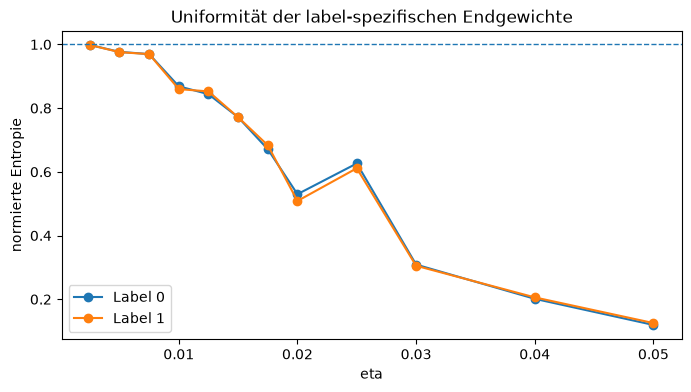

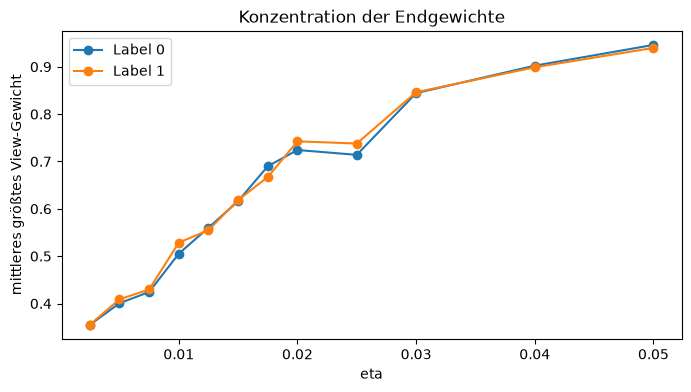

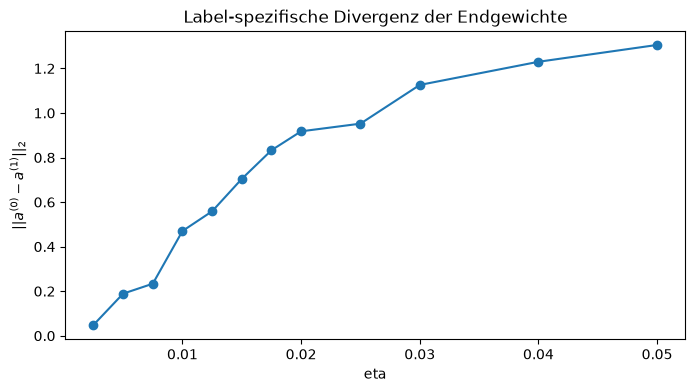


=== Häufigste Endgewichtsmuster insgesamt ===


,label,weight_group,n
7,0,near_uniform,1240
9,0,single_hs,900
10,0,single_naics,675
6,0,mixed,672
8,0,single_am,323
2,0,mix_hs+am,162
4,0,mix_naics+am,108
0,0,mix_am+hs,86
5,0,mix_naics+hs,59
3,0,mix_hs+naics,42


In [33]:
# === Label-spezifische Endgewichte nach eta analysieren ===
import sqlite3, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

VIEWS = ["naics", "hs", "am"]

con = sqlite3.connect(str(CACHE_DB))

df = pd.read_sql_query("""
    SELECT config_key, model, k_value, eta, fold, status, vweights_json
    FROM fold_results
    WHERE model = 'M3GLVQ_Label'
      AND status = 'ok'
      AND vweights_json IS NOT NULL
""", con)

con.close()

# ------------------------------------------------------------
# 1. Gewichte aus JSON extrahieren
# ------------------------------------------------------------
records = []

for _, r in df.iterrows():
    w = json.loads(r["vweights_json"])

    if w.get("kind") != "label":
        continue

    labels = w["labels"]
    a = np.asarray(w["a_sq"], dtype=float)   # shape: (n_labels, 3)

    for i, label in enumerate(labels):
        weights = a[i]

        rec = {
            "config_key": r["config_key"],
            "k_value": r["k_value"],
            "eta": float(r["eta"]),
            "fold": int(r["fold"]),
            "label": str(label),
        }

        for view, val in zip(VIEWS, weights):
            rec[view] = float(val)

        records.append(rec)

W = pd.DataFrame(records)

# ------------------------------------------------------------
# 2. Diagnosegrößen
# ------------------------------------------------------------
U = np.ones(3) / 3

def entropy_norm(row):
    x = row[VIEWS].to_numpy(dtype=float)
    return -(x * np.log(x + 1e-12)).sum() / np.log(3)

def classify_weights(row):
    x = row[VIEWS].to_numpy(dtype=float)
    order = np.argsort(x)[::-1]
    top1, top2, top3 = x[order]
    v1, v2 = VIEWS[order[0]], VIEWS[order[1]]

    # Schwellen bei Bedarf anpassen
    if top1 <= 0.45:
        return "near_uniform"
    elif top1 >= 0.80:
        return f"single_{v1}"
    elif top2 >= 0.25 and top3 <= 0.15:
        return f"mix_{v1}+{v2}"
    else:
        return "mixed"

W["dominant_view"] = W[VIEWS].idxmax(axis=1)
W["max_weight"] = W[VIEWS].max(axis=1)
W["entropy"] = W.apply(entropy_norm, axis=1)
W["dist_uniform"] = np.linalg.norm(
    W[VIEWS].to_numpy() - U,
    axis=1
)
W["weight_group"] = W.apply(classify_weights, axis=1)

# ------------------------------------------------------------
# 3. Abstand zwischen Label-0- und Label-1-Gewichten
#    pro Config/Fold
# ------------------------------------------------------------
wide = W.pivot_table(
    index=["config_key", "k_value", "eta", "fold"],
    columns="label",
    values=VIEWS
)

# funktioniert für Labels "0" und "1"
if ("0" in wide.columns.levels[1]) and ("1" in wide.columns.levels[1]):
    a0 = wide.xs("0", level=1, axis=1)[VIEWS].to_numpy()
    a1 = wide.xs("1", level=1, axis=1)[VIEWS].to_numpy()

    S = wide.reset_index()[["config_key", "k_value", "eta", "fold"]].copy()
    S["label_distance"] = np.linalg.norm(a0 - a1, axis=1)
else:
    S = pd.DataFrame()

# ------------------------------------------------------------
# 4. Übersicht pro eta und Label
# ------------------------------------------------------------
summary = (
    W.groupby(["eta", "label"])
     .agg(
         n=("fold", "size"),
         naics=("naics", "mean"),
         hs=("hs", "mean"),
         am=("am", "mean"),
         entropy=("entropy", "mean"),
         dist_uniform=("dist_uniform", "mean"),
         max_weight=("max_weight", "mean"),
     )
     .reset_index()
)

print("\n=== Mittlere Endgewichte / Uniformität nach eta und Label ===")
display(summary.round(4))

# ------------------------------------------------------------
# 5. Dominante View nach eta und Label
# ------------------------------------------------------------
dominant = (
    W.groupby(["eta", "label", "dominant_view"])
     .size()
     .rename("n")
     .reset_index()
)

dominant["share"] = (
    dominant["n"]
    / dominant.groupby(["eta", "label"])["n"].transform("sum")
)

print("\n=== Anteil dominante View ===")
display(
    dominant.pivot_table(
        index=["eta", "label"],
        columns="dominant_view",
        values="share",
        fill_value=0
    ).round(3)
)


# ------------------------------------------------------------
# 6. Typen der Endgewichte
# ------------------------------------------------------------
groups = (
    W.groupby(["eta", "label", "weight_group"])
     .size()
     .rename("n")
     .reset_index()
)

groups["share"] = (
    groups["n"]
    / groups.groupby(["eta", "label"])["n"].transform("sum")
)

print("\n=== Gewichtsgruppen nach eta und Label ===")
display(
    groups.pivot_table(
        index=["eta", "label"],
        columns="weight_group",
        values="share",
        fill_value=0
    ).round(3)
)

# ------------------------------------------------------------
# 7. Label-Unterschied S_t nach eta
# ------------------------------------------------------------
if len(S):
    s_summary = (
        S.groupby("eta")["label_distance"]
         .agg(["count", "mean", "std", "median"])
         .reset_index()
    )

    print("\n=== Abstand zwischen Label-0- und Label-1-Gewichten ===")
    display(s_summary.round(4))

# ------------------------------------------------------------
# 8. Plots
# ------------------------------------------------------------

# A: Entropie nach eta
fig, ax = plt.subplots(figsize=(8, 4))
for label, d in summary.groupby("label"):
    d = d.sort_values("eta")
    ax.plot(d["eta"], d["entropy"], marker="o", label=f"Label {label}")

ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_xlabel("eta")
ax.set_ylabel("normierte Entropie")
ax.set_title("Uniformität der label-spezifischen Endgewichte")
ax.legend()
plt.show()


# B: maximales Gewicht nach eta
fig, ax = plt.subplots(figsize=(8, 4))
for label, d in summary.groupby("label"):
    d = d.sort_values("eta")
    ax.plot(d["eta"], d["max_weight"], marker="o", label=f"Label {label}")

ax.set_xlabel("eta")
ax.set_ylabel("mittleres größtes View-Gewicht")
ax.set_title("Konzentration der Endgewichte")
ax.legend()
plt.show()


# C: Abstand Label 0 vs. Label 1
if len(S):
    splot = S.groupby("eta")["label_distance"].mean().reset_index()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(
        splot["eta"],
        splot["label_distance"],
        marker="o"
    )
    ax.set_xlabel("eta")
    ax.set_ylabel(r"$||a^{(0)} - a^{(1)}||_2$")
    ax.set_title("Label-spezifische Divergenz der Endgewichte")
    plt.show()


# ------------------------------------------------------------
# 9. Optional: wichtigste Gewichtsgruppen insgesamt
# ------------------------------------------------------------
print("\n=== Häufigste Endgewichtsmuster insgesamt ===")
display(
    W.groupby(["label", "weight_group"])
     .size()
     .rename("n")
     .reset_index()
     .sort_values(["label", "n"], ascending=[True, False])
)

In [ ]:
import sqlite3, json
import numpy as np, pandas as pd
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score

con = sqlite3.connect(str(CACHE_DB))

# --- Überblick: wie viele Fold-Zeilen, je Status/Modell ---
total = con.execute("SELECT COUNT(*) FROM fold_results").fetchone()[0]
print("Fold-Zeilen gesamt:", total)
print(pd.read_sql_query(
    "SELECT model, status, COUNT(*) AS n FROM fold_results GROUP BY model, status "
    "ORDER BY model, status", con))

# --- welche Configs sind KOMPLETT (alle Folds ok)? ---
rows = pd.read_sql_query(
    "SELECT config_key, model, k_value, eta, fold, status, y_true_json, y_pred_json "
    "FROM fold_results", con)

def _agg(g):
    ok = g[g.status == "ok"]
    if len(ok) == 0:
        return pd.Series({"n_folds": len(g), "n_ok": 0,
                          "bal_acc": np.nan, "recall": np.nan, "f1": np.nan})
    yt = np.concatenate([np.array(json.loads(s)) for s in ok.y_true_json])
    yp = np.concatenate([np.array(json.loads(s)) for s in ok.y_pred_json])
    return pd.Series({"n_folds": len(g), "n_ok": len(ok),
                      "bal_acc": balanced_accuracy_score(yt, yp),
                      "recall":  recall_score(yt, yp, pos_label=1, zero_division=0),
                      "f1":      f1_score(yt, yp, average="macro")})

summary = (rows.groupby(["config_key", "model", "k_value", "eta"])
                .apply(_agg).reset_index())

# erwartete Foldzahl (dein Lauf: 10; Synthetik: 3)
EXPECTED_FOLDS = 10
complete = summary[summary.n_ok == EXPECTED_FOLDS].copy()
partial  = summary[(summary.n_ok > 0) & (summary.n_ok < EXPECTED_FOLDS)]

print(f"\nConfigs gesamt angefangen: {len(summary)} | "
      f"komplett ({EXPECTED_FOLDS} Folds): {len(complete)} | "
      f"angefangen/unvollständig: {len(partial)}")

# --- beste komplette Runs je Modell ---
print("\n=== Beste komplette Runs (bal_acc) ===")
for model in sorted(complete.model.unique()):
    d = complete[complete.model == model].sort_values("bal_acc", ascending=False)
    print(f"\n--- {model} ---")
    print(d[["k_value", "eta", "bal_acc","recall", "f1", "n_ok"]].head(5).to_string(index=False))

con.close()

## Block 4 — repeated-OOF-Correctness + Verknüpfung (Neuerung 2)
Je Gewinner-Config R Wiederholungen (reseed der Fold-Layout → nur weitere gecachte Fold-Jobs),
per-Kunde-Prediction via `va_idx` aggregiert → `correct_rate_i`, verknüpft mit `purity_i`/`margin_i`.

In [ ]:
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score

def _agg(g):
    ok = g[g.status == "ok"]
    if len(ok) == 0:
        return pd.Series({"n_folds": len(g), "n_ok": 0,
                          "bal_acc": np.nan, "recall": np.nan, "f1": np.nan})
    yt = np.concatenate([np.array(json.loads(s)) for s in ok.y_true_json])
    yp = np.concatenate([np.array(json.loads(s)) for s in ok.y_pred_json])
    return pd.Series({"n_folds": len(g), "n_ok": len(ok),
                      "bal_acc": balanced_accuracy_score(yt, yp),
                      "recall":  recall_score(yt, yp, pos_label=1, zero_division=0),
                      "f1":      f1_score(yt, yp, average="macro")})

In [ ]:
linked, manifest = repeated_oof.run_and_link(
    best, bundle.DL, bundle.y, bundle.codes,
    pointwise_df=wide_df,
    cache_db=CACHE_DB,
    T=ROOF["T"], n_splits=ROOF["n_splits"], n_repeats=ROOF["n_repeats"],
    random_state0=1000, base_seed=BASE_SEED, n_jobs=N_JOBS,
)
for m_, df_ in linked.items():
    print(m_, "| Kunden:", len(df_), "| mittlere correct_rate:",
          round(float(df_["correct_rate"].mean()), 3))
list(linked.values())[0].head()

## Block 3b — Gewichtsprofil-Cluster + Fixed-Weight-Profile
Die per-Fold-Gewichte (a²) der Global-Suche liegen bereits im Cache. Wir clustern sie,
bilden Fixed-Profile (kanonische Single-View-Ecken + Cluster-Zentroide) und evaluieren sie
mit **eingefrorenen** Gewichten (`eta=0`, `v_init=√mixture` wegen der quadratischen Param).
Ergebnis: `fixed_oof_df` je Kunde → speist Tabelle 9.

In [ ]:
fw = WP.collect_fold_weights(CACHE_DB, model="M3GLVQ_Global")
print("Global per-Fold-Gewichte im Cache:", len(fw))

if len(fw) >= 2:
    df_high, thr = WP.select_top_runs(fw, quantile=(0.0 if USE_SYNTHETIC else 0.9))
    clus = WP.cluster_weight_profiles(df_high, n_clusters=(2 if USE_SYNTHETIC else 5))
    try:
        display(WP.cluster_summary(clus))
    except NameError:
        print(WP.cluster_summary(clus))
    g = best.get("M3GLVQ_Global", {"K0": 6, "K1": 6})
    profiles = WP.build_fixed_profiles(clus, K=(g["K0"], g["K1"]))
else:
    profiles = WP.build_fixed_profiles(None, K=(3, 3))   # nur kanonische Ecken

fixed_oof_df = WP.run_fixed_profiles(
    profiles, bundle.DL, bundle.y, bundle.codes, CACHE_DB,
    T=ROOF["T"], n_splits=(3 if USE_SYNTHETIC else 10),
    random_state=RANDOM_STATE, base_seed=BASE_SEED, n_jobs=N_JOBS,
)
profile_map = WP.default_profile_map(profiles)
print("Fixed-Profile:", [p["profile_name"] for p in profiles])
fixed_oof_df.head()

## Block 5 — Paper-Tabellen 5.1–5.9 (tie-safe konsistent)

In [ ]:
tables = {}
tables["distance_distribution"]      = PT.build_distance_distribution_table(bundle.matrices_norm)
tables["structural_characteristics"] = PT.build_structural_characteristics_table(struct["single_summary_df"])
tables["pearson"]                    = PT.build_pearson_correlation_table(struct_dir)
tables["knn_overlap"]                = PT.build_knn_overlap_table(struct_dir, k=10)
tables["agreement"]                  = PT.build_agreement_table(struct_dir)
tables["single_view_baseline"]       = PT.build_single_view_baseline_table(sv["summary_df"])
tables["structure_prediction_dom"]   = PT.build_structure_prediction_dominance_table(
    wide_df, structure_metric="knn_purity")
# Tab. 9 (fixed-profile dominance) braucht die Fixed-Weight-OOF-Suite — optional, separat.

for name, t in tables.items():
    print("\n###", name)
    try:
        display(t)
    except NameError:
        print(t)

In [ ]:
from src.analysis.paper_tables import build_fixed_profile_dominance_table
try:
    t9 = build_fixed_profile_dominance_table(wide_df, fixed_oof_df, profile_map)
    print("### fixed_profile_dominance (Tab. 9)")
    try:
        display(t9)
    except NameError:
        print(t9)
except Exception as e:
    print("Tab. 9 benötigt fixed_oof_df aus Block 3b:", e)

### Sanity-Check (Arbeitsanweisung §2)
Aggregat-Ranking der kNN-Purity muss **Industry > Products > Applications** bleiben
(die *punktweise* Dominanz darf sich durch tie-safe verschieben, das Aggregat nicht).

In [ ]:
chars = tables["structural_characteristics"].set_index("Matrix")["kNN Pur."]
print(chars.sort_values(ascending=False))
print("Ranking:", " > ".join(list(chars.sort_values(ascending=False).index)[:3]))

## Block 6 — Figur: Struktur-vs-Prädiktion (Boxplot über Purity)

In [ ]:
joined_long = Path(ANALYSIS) / "pointwise" / "structure_single_view_joined_long.csv"
try:
    fig = plot_structure_vs_prediction_boxplot(str(joined_long), metric="knn_purity")
    fig
except Exception as e:
    print("Figur benötigt joined_long.csv aus Block-5-Pointwise:", e)

## Phase 6 — Lernkurven-Kopf (alt/neu, implementierst du selbst)
Modelle liegen sauber vor. Global unterscheidet sich bei **jedem** η (Simplex→quadratisch);
Label erst bei η ≳ 0.03 (best-so-far greift bei nicht-monotoner Kurve).

In [ ]:
from src.models import GlobalOld, GlobalNew, LabelOld, LabelNew
# Skelett:
# etas = [0.01, 0.03, 0.05]
# for name, cls in [("Global OLD", GlobalOld), ("Global NEW", GlobalNew),
#                   ("Label OLD", LabelOld),  ("Label NEW", LabelNew)]:
#     for eta in etas:
#         clf = cls(K={0: 6, 1: 6}, T=SEARCH["T"], eta=eta, base_seed=BASE_SEED)
#         clf.fit(bundle.DL, bundle.y)   # Loss-Kurve aus clf._loss_history ziehen
print("Modelle bereit:", GlobalOld.__name__, GlobalNew.__name__, LabelOld.__name__, LabelNew.__name__)